# Conditional Pet Facial Expression Generation

Given a class label (`Angry`, `Happy`, `Sad`), generate a synthetic pet face image.

Three models implemented and compared:
1. **Conditional VAE (CVAE)** — fast baseline, ~5 min training
2. **Conditional DDPM** — UNet diffusion with classifier-free guidance, ~25 min
3. **CLIP-conditioned DDPM** — semantic conditioning via frozen CLIP text encoder, ~30 min

## Section 1 — Setup & Data Pipeline

In [1]:
import pathlib, math, random, time, subprocess
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt
from scipy import linalg

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

# ── Constants ─────────────────────────────────────────────────────────────────
DEVICE      = torch.device("cpu")
IMG_SIZE    = 64
NUM_CLASSES = 3
CLASS_NAMES = ["Angry", "Happy", "Sad"]
CTOI        = {c: i for i, c in enumerate(CLASS_NAMES)}

# Dataset-wide RGB stats (from EDA notebook)
IMG_MEAN = [0.511, 0.463, 0.408]
IMG_STD  = [0.159, 0.143, 0.140]

DATA_ROOT = pathlib.Path("data/classification-of-pet-facial-expression/train/train")
print("Device:", DEVICE)
print("Images found:", sum(1 for _ in DATA_ROOT.glob("*/*.jpg")))

Device: cpu
Images found: 450


In [2]:
class PetDataset(Dataset):
    """Loads pet expression images from train/{Angry,Happy,Sad}/ directories."""
    def __init__(self, transform=None):
        self.samples   = []
        self.transform = transform
        for cls_dir in sorted(DATA_ROOT.iterdir()):
            if not cls_dir.is_dir():
                continue
            label = CTOI[cls_dir.name]
            for img_path in sorted(cls_dir.glob("*.jpg")):
                self.samples.append((img_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

In [3]:
# ── Transforms ───────────────────────────────────────────────────────────────
train_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    T.ToTensor(),
    T.Normalize(mean=IMG_MEAN, std=IMG_STD),
])

val_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMG_MEAN, std=IMG_STD),
])

# ── DataLoaders ──────────────────────────────────────────────────────────────
# num_workers=0 required on macOS to avoid multiprocessing fork issues
train_ds     = PetDataset(transform=train_tfms)
real_ds      = PetDataset(transform=val_tfms)   # no augmentation, for FID/eval

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0)
real_loader  = DataLoader(real_ds,  batch_size=64, shuffle=False, num_workers=0)
print(f"Train dataset: {len(train_ds)} images, {len(train_loader)} batches")

Train dataset: 450 images, 15 batches


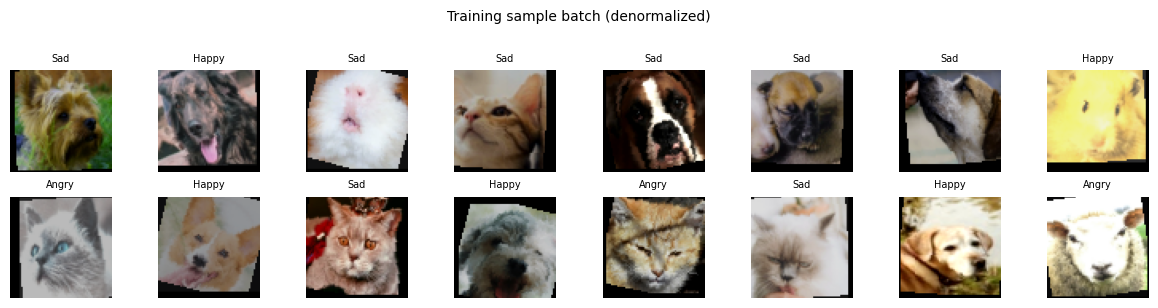

In [4]:
def denorm(t):
    """Undo normalization for display: (C,H,W) or (B,C,H,W) → [0,1] clipped."""
    mean = torch.tensor(IMG_MEAN).view(1, 3, 1, 1)
    std  = torch.tensor(IMG_STD ).view(1, 3, 1, 1)
    if t.dim() == 3:
        t = t.unsqueeze(0)
    return (t * std + mean).clamp(0, 1)

def show_grid(imgs, labels=None, ncols=8, title=""):
    """Display a grid of (B,3,H,W) tensors (already denormed to [0,1])."""
    n    = len(imgs)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.5, nrows * 1.5))
    axes = np.array(axes).reshape(nrows, ncols)
    for i in range(nrows * ncols):
        ax = axes[i // ncols, i % ncols]
        if i < n:
            ax.imshow(imgs[i].permute(1, 2, 0).numpy())
            if labels is not None:
                ax.set_title(CLASS_NAMES[labels[i]], fontsize=7)
        ax.axis("off")
    if title:
        fig.suptitle(title, fontsize=10, y=1.01)
    plt.tight_layout()
    plt.show()

# ── Quick visual sanity check ─────────────────────────────────────────────────
batch_imgs, batch_labels = next(iter(train_loader))
show_grid(denorm(batch_imgs[:16]), batch_labels[:16].tolist(), title="Training sample batch (denormalized)")

## Section 2 — Conditional VAE (CVAE) Baseline

The encoder compresses 64×64 RGB images to a 128-dim Gaussian latent.  
Class label is embedded (dim 64) and concatenated to the latent before decoding.  
**KL annealing** (β: 0 → 1 over 20 epochs) prevents posterior collapse on 450 images.

In [14]:
LATENT_DIM  = 128
LABEL_EMB   = 64   # class embedding dimension shared by encoder and decoder

class CVAEEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3,   32,  4, stride=2, padding=1),  # 64→32
            nn.BatchNorm2d(32),  nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32,  64,  4, stride=2, padding=1),  # 32→16
            nn.BatchNorm2d(64),  nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64,  128, 4, stride=2, padding=1),  # 16→8
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),  # 8→4
            nn.BatchNorm2d(256), nn.LeakyReLU(0.2, inplace=True),
        )
        # After conv: (B, 256, 4, 4) → flatten → 4096
        # Concat label emb (64) → 4160
        self.fc    = nn.Sequential(nn.Linear(4096 + LABEL_EMB, 512), nn.ReLU(inplace=True))
        self.fc_mu = nn.Linear(512, LATENT_DIM)
        self.fc_lv = nn.Linear(512, LATENT_DIM)

    def forward(self, x, label_emb):
        h = self.conv(x).flatten(1)          # (B, 4096)
        h = torch.cat([h, label_emb], dim=1) # (B, 4160)
        h = self.fc(h)
        return self.fc_mu(h), self.fc_lv(h)


class CVAEDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Input: z (128) + label_emb (64) = 192
        self.fc = nn.Sequential(
            nn.Linear(LATENT_DIM + LABEL_EMB, 512), nn.ReLU(inplace=True),
            nn.Linear(512, 256 * 4 * 4),             nn.ReLU(inplace=True),
        )
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),  # 4→8
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64,  4, stride=2, padding=1),  # 8→16
            nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64,  32,  4, stride=2, padding=1),  # 16→32
            nn.BatchNorm2d(32),  nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32,  3,   4, stride=2, padding=1),  # 32→64
            # No Tanh: decoder predicts in the same normalized pixel space as input.
            # Tanh would cap at [-1,1] but normalized images live in ~[-3,3].
        )

    def forward(self, z, label_emb):
        h = torch.cat([z, label_emb], dim=1)  # (B, 192)
        h = self.fc(h).view(-1, 256, 4, 4)
        return self.deconv(h)


class CVAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb     = nn.Embedding(NUM_CLASSES, LABEL_EMB)
        self.encoder = CVAEEncoder()
        self.decoder = CVAEDecoder()

    def encode(self, x, y):
        return self.encoder(x, self.emb(y))

    def reparametrize(self, mu, log_var):
        std = (0.5 * log_var).exp()
        return mu + std * torch.randn_like(std)

    def decode(self, z, y):
        return self.decoder(z, self.emb(y))

    def forward(self, x, y):
        mu, lv = self.encode(x, y)
        z      = self.reparametrize(mu, lv)
        x_hat  = self.decode(z, y)
        return x_hat, mu, lv


cvae = CVAE().to(DEVICE)
total_params = sum(p.numel() for p in cvae.parameters())
print(f"CVAE parameters: {total_params:,}")

CVAE parameters: 5,843,459


In [15]:
def cvae_loss(x, x_hat, mu, log_var, beta):
    """ELBO: MSE reconstruction + beta-weighted KL divergence."""
    recon = F.mse_loss(x_hat, x, reduction="sum") / x.size(0)
    kld   = -0.5 * (1 + log_var - mu.pow(2) - log_var.exp()).sum(1).mean()
    return recon + beta * kld, recon.item(), kld.item()


def train_cvae(model, loader, epochs=50, lr=1e-3, kl_anneal_epochs=20):
    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-5)
    history = {"total": [], "recon": [], "kld": []}
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        # KL annealing: linearly ramp beta from 0 to 1 over kl_anneal_epochs
        beta = min(1.0, epoch / kl_anneal_epochs)
        epoch_total = epoch_recon = epoch_kld = 0.0
        model.train()

        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            x_hat, mu, lv = model(x, y)
            loss, r, k = cvae_loss(x, x_hat, mu, lv, beta)
            opt.zero_grad(); loss.backward(); opt.step()
            epoch_total += loss.item(); epoch_recon += r; epoch_kld += k

        sched.step()
        n = len(loader)
        history["total"].append(epoch_total / n)
        history["recon"].append(epoch_recon / n)
        history["kld"  ].append(epoch_kld   / n)

        if epoch % 10 == 0:
            elapsed = time.time() - t0
            print(f"Epoch {epoch:3d}/{epochs} | β={beta:.2f} | "
                  f"total={history['total'][-1]:.3f}  "
                  f"recon={history['recon'][-1]:.3f}  "
                  f"kld={history['kld'][-1]:.3f}  "
                  f"[{elapsed:.0f}s elapsed]")
    return history


print("Starting CVAE training (≈5 min on CPU) ...")
cvae_hist = train_cvae(cvae, train_loader, epochs=50)

Starting CVAE training (≈5 min on CPU) ...
Epoch  10/50 | β=0.50 | total=23785.497  recon=23552.629  kld=465.737  [72s elapsed]
Epoch  20/50 | β=1.00 | total=18829.090  recon=18482.846  kld=346.243  [145s elapsed]
Epoch  30/50 | β=1.00 | total=18881.926  recon=18595.117  kld=286.809  [211s elapsed]
Epoch  40/50 | β=1.00 | total=16104.329  recon=15842.000  kld=262.329  [282s elapsed]
Epoch  50/50 | β=1.00 | total=17092.401  recon=16835.031  kld=257.370  [332s elapsed]


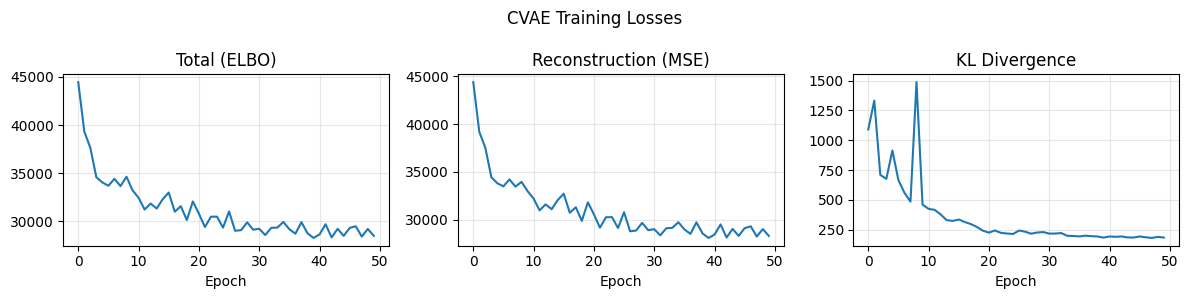

In [7]:
# ── Loss curves ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, key, title in zip(axes,
                           ["total", "recon", "kld"],
                           ["Total (ELBO)", "Reconstruction (MSE)", "KL Divergence"]):
    ax.plot(cvae_hist[key])
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.grid(True, alpha=0.3)
plt.suptitle("CVAE Training Losses", fontsize=12)
plt.tight_layout(); plt.show()

In [ ]:
@torch.no_grad()
def generate_cvae(model, class_idx, n=8, temp=0.8):
    """Sample z~N(0,I)*temp conditioned on class_idx, decode to normalized pixel space."""
    model.eval()
    z      = torch.randn(n, LATENT_DIM, device=DEVICE) * temp
    labels = torch.full((n,), class_idx, dtype=torch.long, device=DEVICE)
    return model.decode(z, labels)   # (n, 3, 64, 64) in normalized space


# ── 3×8 generation grid ───────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 8, figsize=(16, 6))
for row, cls_idx in enumerate(range(NUM_CLASSES)):
    gen         = generate_cvae(cvae, cls_idx, n=8)
    gen_display = denorm(gen)   # normalized → [0,1] for display
    for col in range(8):
        axes[row, col].imshow(gen_display[col].permute(1, 2, 0).numpy())
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(CLASS_NAMES[cls_idx], fontsize=9, rotation=0,
                            labelpad=40, va="center")
plt.suptitle("CVAE Generated Samples (temp=0.8)", fontsize=12)
plt.tight_layout(); plt.show()

In [ ]:
# ── Reconstruction sanity check ───────────────────────────────────────────────
cvae.eval()
x_real, y_real = next(iter(real_loader))
x_real, y_real = x_real[:8].to(DEVICE), y_real[:8].to(DEVICE)
with torch.no_grad():
    x_recon, _, _ = cvae(x_real, y_real)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(denorm(x_real[i])[0].permute(1, 2, 0).numpy())
    axes[0, i].axis("off")
    axes[0, i].set_title(CLASS_NAMES[y_real[i].item()], fontsize=7)
    # x_recon is in normalized space — use denorm() exactly like real images
    axes[1, i].imshow(denorm(x_recon[i])[0].permute(1, 2, 0).numpy())
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Real",          fontsize=9, rotation=0, labelpad=40, va="center")
axes[1, 0].set_ylabel("Reconstructed", fontsize=9, rotation=0, labelpad=40, va="center")
plt.suptitle("CVAE Reconstruction Check", fontsize=12)
plt.tight_layout(); plt.show()

## Section 3 — Conditional DDPM with Classifier-Free Guidance

A lightweight UNet denoises images over T=1000 steps.  
Class conditioning is injected at every resolution level via addition to the time embedding.  
**Classifier-Free Guidance (CFG)**: 10% of training steps drop the label to a null token;  
at inference `ε = ε_uncond + w·(ε_cond − ε_uncond)` with w=3–5 sharpens class-specific features.  
**DDIM sampling** (50 steps) keeps generation under 30s on CPU.

In [10]:
T_STEPS = 1000
NULL_TOKEN = NUM_CLASSES  # index 3 = unconditional null class for CFG

# ── Noise schedule (linear beta) ─────────────────────────────────────────────
betas             = torch.linspace(1e-4, 0.02, T_STEPS)
alphas            = 1.0 - betas
alphas_cumprod    = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
sqrt_acp          = alphas_cumprod.sqrt()
sqrt_1m_acp       = (1.0 - alphas_cumprod).sqrt()
# For posterior q(x_{t-1}|x_t, x_0)
posterior_var     = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)


def q_sample(x0, t, noise=None):
    """Forward diffusion: add t-level noise to x0."""
    if noise is None:
        noise = torch.randn_like(x0)
    s1 = sqrt_acp[t].view(-1, 1, 1, 1)
    s2 = sqrt_1m_acp[t].view(-1, 1, 1, 1)
    return s1 * x0 + s2 * noise, noise


print(f"β range: [{betas[0]:.5f}, {betas[-1]:.4f}]")
print(f"ā_T (signal remaining at T): {alphas_cumprod[-1]:.6f}")

β range: [0.00010, 0.0200]
ā_T (signal remaining at T): 0.000040


In [11]:
EMB_DIM = 256   # time + class embedding projection dimension

def sinusoidal_embedding(t, dim=128):
    """Standard sinusoidal positional embedding for timestep t. t: (B,) → (B, dim)."""
    half  = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half, dtype=torch.float32) / half)
    args  = t[:, None].float() * freqs[None]
    return torch.cat([args.sin(), args.cos()], dim=-1)


class TimeClassEmb(nn.Module):
    """Sinusoidal time emb + class label emb → projected to EMB_DIM."""
    def __init__(self, emb_dim=EMB_DIM, num_classes=NUM_CLASSES + 1):
        # num_classes+1 to include the null token (index NUM_CLASSES) for CFG
        super().__init__()
        self.time_proj = nn.Sequential(
            nn.Linear(128, emb_dim), nn.SiLU(),
            nn.Linear(emb_dim, emb_dim),
        )
        self.class_emb = nn.Embedding(num_classes, emb_dim)

    def forward(self, t, y):
        te = self.time_proj(sinusoidal_embedding(t))   # (B, emb_dim)
        ce = self.class_emb(y)                          # (B, emb_dim)
        return te + ce                                  # (B, emb_dim)


class ResBlock(nn.Module):
    """ResNet block with GroupNorm and time+class conditioning injected via addition."""
    def __init__(self, in_ch, out_ch, emb_dim=EMB_DIM):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.emb_proj = nn.Linear(emb_dim, out_ch)
        self.act  = nn.SiLU()
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, emb):
        h = self.act(self.norm1(x))
        h = self.conv1(h)
        h = h + self.emb_proj(self.act(emb))[:, :, None, None]
        h = self.act(self.norm2(h))
        h = self.conv2(h)
        return h + self.skip(x)


class AttentionBlock(nn.Module):
    """Self-attention block (used at 8×8 and 16×16 resolutions)."""
    def __init__(self, ch):
        super().__init__()
        self.norm = nn.GroupNorm(8, ch)
        self.qkv  = nn.Conv2d(ch, ch * 3, 1)
        self.proj = nn.Conv2d(ch, ch, 1)
        self.scale = ch ** -0.5

    def forward(self, x):
        B, C, H, W = x.shape
        h   = self.norm(x)
        qkv = self.qkv(h).reshape(B, 3, C, H * W)
        q, k, v = qkv.unbind(1)
        attn = torch.softmax((q.transpose(-1, -2) @ k) * self.scale, dim=-1)
        h    = (attn @ v.transpose(-1, -2)).transpose(-1, -2).reshape(B, C, H, W)
        return x + self.proj(h)


print("Building blocks defined.")

Building blocks defined.


In [12]:
class UNet(nn.Module):
    """
    Conditional UNet for DDPM.

    Channel widths: 64 → 128 → 256 → 256
    Attention at 8×8 and 16×16 spatial resolutions.
    Time + class conditioning injected into every ResBlock via EMB_DIM=256 vector.
    """
    def __init__(self, emb_dim=EMB_DIM):
        super().__init__()
        self.time_class_emb = TimeClassEmb(emb_dim)

        # ── Encoder ──────────────────────────────────────────────────────────
        self.init_conv = nn.Conv2d(3, 64, 3, padding=1)

        self.down1_res  = ResBlock(64,  128, emb_dim)
        self.down1_pool = nn.Conv2d(128, 128, 3, stride=2, padding=1)  # 64→32

        self.down2_res  = ResBlock(128, 256, emb_dim)
        self.down2_attn = AttentionBlock(256)
        self.down2_pool = nn.Conv2d(256, 256, 3, stride=2, padding=1)  # 32→16

        self.down3_res  = ResBlock(256, 256, emb_dim)
        self.down3_attn = AttentionBlock(256)
        self.down3_pool = nn.Conv2d(256, 256, 3, stride=2, padding=1)  # 16→8

        # ── Bottleneck ────────────────────────────────────────────────────────
        self.mid_res1 = ResBlock(256, 256, emb_dim)
        self.mid_attn = AttentionBlock(256)
        self.mid_res2 = ResBlock(256, 256, emb_dim)

        # ── Decoder ──────────────────────────────────────────────────────────
        self.up3_up   = nn.Upsample(scale_factor=2, mode="nearest")   # 8→16
        self.up3_res  = ResBlock(256 + 256, 256, emb_dim)
        self.up3_attn = AttentionBlock(256)

        self.up2_up   = nn.Upsample(scale_factor=2, mode="nearest")   # 16→32
        self.up2_res  = ResBlock(256 + 128, 128, emb_dim)
        self.up2_attn = AttentionBlock(128)

        self.up1_up   = nn.Upsample(scale_factor=2, mode="nearest")   # 32→64
        self.up1_res  = ResBlock(128 + 64,  64,  emb_dim)

        # ── Output ────────────────────────────────────────────────────────────
        self.out = nn.Sequential(
            nn.GroupNorm(8, 64),
            nn.SiLU(),
            nn.Conv2d(64, 3, 1),
        )

    def forward(self, x, t, y):
        emb = self.time_class_emb(t, y)  # (B, EMB_DIM)

        # Encoder
        h0 = self.init_conv(x)                                    # (B, 64, 64, 64)
        h1 = self.down1_pool(self.down1_res(h0, emb))             # (B,128, 32, 32)
        h2 = self.down2_pool(self.down2_attn(self.down2_res(h1, emb)))  # (B,256, 16, 16)
        h3 = self.down3_pool(self.down3_attn(self.down3_res(h2, emb)))  # (B,256,  8,  8)

        # Bottleneck
        h  = self.mid_res1(h3, emb)
        h  = self.mid_attn(h)
        h  = self.mid_res2(h, emb)

        # Decoder (skip connections via concatenation)
        h  = self.up3_res(torch.cat([self.up3_up(h), h2], dim=1), emb)
        h  = self.up3_attn(h)
        h  = self.up2_res(torch.cat([self.up2_up(h), h1], dim=1), emb)
        h  = self.up2_attn(h)
        h  = self.up1_res(torch.cat([self.up1_up(h), h0], dim=1), emb)

        return self.out(h)


unet = UNet().to(DEVICE)
total_params = sum(p.numel() for p in unet.parameters())
print(f"UNet parameters: {total_params:,}")

# Quick shape check
with torch.no_grad():
    _x = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
    _t = torch.randint(0, T_STEPS, (2,))
    _y = torch.zeros(2, dtype=torch.long)
    _out = unet(_x, _t, _y)
    print(f"UNet output shape: {_out.shape}  ✓")

UNet parameters: 10,358,339
UNet output shape: torch.Size([2, 3, 64, 64])  ✓


In [13]:
DDPM_EPOCHS   = 100
CFG_DROP_PROB = 0.1   # probability of dropping the class label during training

ddpm_opt   = torch.optim.AdamW(unet.parameters(), lr=2e-4, weight_decay=1e-4)
ddpm_sched = torch.optim.lr_scheduler.CosineAnnealingLR(ddpm_opt, T_max=DDPM_EPOCHS)

# Smaller batch to keep memory manageable with the larger UNet
ddpm_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0)

ddpm_losses = []
ddpm_checkpoints = {}   # store state dicts at epochs 25, 50, 75, 100
t0 = time.time()

print("Starting DDPM training (≈25 min on CPU) ...")
unet.train()

for epoch in range(1, DDPM_EPOCHS + 1):
    epoch_loss = 0.0
    for x0, y in ddpm_loader:
        x0, y = x0.to(DEVICE), y.to(DEVICE)

        # Classifier-free guidance: randomly replace label with null token
        mask = torch.rand(y.shape[0]) < CFG_DROP_PROB
        y_cfg = y.clone()
        y_cfg[mask] = NULL_TOKEN

        t   = torch.randint(0, T_STEPS, (x0.size(0),), device=DEVICE)
        xt, eps = q_sample(x0, t)
        eps_pred = unet(xt, t, y_cfg)
        loss = F.mse_loss(eps_pred, eps)

        ddpm_opt.zero_grad(); loss.backward(); ddpm_opt.step()
        epoch_loss += loss.item()

    ddpm_sched.step()
    avg = epoch_loss / len(ddpm_loader)
    ddpm_losses.append(avg)

    if epoch % 25 == 0:
        elapsed = time.time() - t0
        print(f"Epoch {epoch:3d}/{DDPM_EPOCHS} | loss={avg:.4f} | [{elapsed:.0f}s]")
        ddpm_checkpoints[epoch] = {k: v.clone() for k, v in unet.state_dict().items()}

print("Training complete.")

Starting DDPM training (≈25 min on CPU) ...
Epoch  25/100 | loss=0.0944 | [3403s]


KeyboardInterrupt: 

In [ ]:
@torch.no_grad()
def ddim_sample(model, class_idx, n=8, ddim_steps=50, guidance_scale=4.0, eta=0.0):
    """
    DDIM sampling with classifier-free guidance.
    eta=0.0 → deterministic (fastest, most stable on CPU).
    guidance_scale: 1.0 = no guidance, 3-5 recommended.
    """
    model.eval()
    y_cond   = torch.full((n,), class_idx,  dtype=torch.long, device=DEVICE)
    y_uncond = torch.full((n,), NULL_TOKEN,  dtype=torch.long, device=DEVICE)

    # Evenly-spaced timesteps
    step_indices = torch.linspace(T_STEPS - 1, 0, ddim_steps + 1).long()
    xt = torch.randn(n, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)

    for i in range(ddim_steps):
        t_curr = step_indices[i].expand(n)
        t_prev = step_indices[i + 1].expand(n)

        # Double forward pass for CFG
        eps_cond   = model(xt, t_curr, y_cond)
        eps_uncond = model(xt, t_curr, y_uncond)
        eps        = eps_uncond + guidance_scale * (eps_cond - eps_uncond)

        acp_t  = alphas_cumprod[t_curr[0]].item()
        acp_tp = alphas_cumprod[t_prev[0]].item() if t_prev[0] > 0 else 1.0

        # Predict x0
        x0_pred = (xt - math.sqrt(1 - acp_t) * eps) / math.sqrt(acp_t)
        x0_pred = x0_pred.clamp(-1, 1)

        # DDIM step
        sigma = eta * math.sqrt((1 - acp_tp) / (1 - acp_t)) * math.sqrt(1 - acp_t / acp_tp)
        noise = torch.randn_like(xt) if eta > 0 else 0
        xt    = (math.sqrt(acp_tp) * x0_pred
                 + math.sqrt(1 - acp_tp - sigma ** 2) * eps
                 + sigma * noise)

    return xt   # (n, 3, 64, 64) in approximately normalized pixel range


# ── DDPM loss curve ───────────────────────────────────────────────────────────
plt.figure(figsize=(8, 3))
plt.plot(ddpm_losses)
plt.title("DDPM Training Loss (MSE noise prediction)"); plt.xlabel("Epoch")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
print(f"Final loss: {ddpm_losses[-1]:.4f}")

In [ ]:
# ── Progress samples: quality at epochs 25, 50, 75, 100 ──────────────────────
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
checkpoint_epochs = sorted(ddpm_checkpoints.keys())

for row, ckpt_epoch in enumerate(checkpoint_epochs):
    unet.load_state_dict(ddpm_checkpoints[ckpt_epoch])
    # Use Happy (class 1) as representative class for progress check
    samples = ddim_sample(unet, class_idx=1, n=8, ddim_steps=50)
    samples_display = denorm(samples)
    for col in range(8):
        axes[row, col].imshow(samples_display[col].permute(1, 2, 0).numpy())
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(f"Epoch {ckpt_epoch}", fontsize=9, rotation=0,
                            labelpad=50, va="center")

# Restore final weights
unet.load_state_dict(ddpm_checkpoints[max(ddpm_checkpoints.keys())])
plt.suptitle("DDPM Generation Progress (Happy class)", fontsize=12)
plt.tight_layout(); plt.show()

In [ ]:
# ── Final DDPM 3×8 generation grid ───────────────────────────────────────────
fig, axes = plt.subplots(3, 8, figsize=(16, 6))
for row, cls_idx in enumerate(range(NUM_CLASSES)):
    samples = ddim_sample(unet, class_idx=cls_idx, n=8, ddim_steps=50, guidance_scale=4.0)
    samples_display = denorm(samples)
    for col in range(8):
        axes[row, col].imshow(samples_display[col].permute(1, 2, 0).numpy())
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(CLASS_NAMES[cls_idx], fontsize=9, rotation=0,
                            labelpad=40, va="center")
plt.suptitle("DDPM Generated Samples (guidance_scale=4.0)", fontsize=12)
plt.tight_layout(); plt.show()

## Section 4 — CLIP-Conditioned DDPM

Instead of a one-hot label embedding, we condition on rich 512-dim CLIP text embeddings.  
CLIP encodes semantic knowledge (e.g., "angry" ↔ bared teeth, tense posture) that  
may improve generation even without retraining CLIP on pet images.

The UNet architecture is identical to Section 3, with `TimeClassEmb` replaced by  
`CLIPTimeEmb` which projects the 512-dim CLIP vector to the same 256-dim conditioning space.

In [ ]:
# Install transformers (needed for CLIP text encoder)
subprocess.run(["pip", "install", "transformers", "-q"], check=True)
print("transformers installed.")

from transformers import CLIPTextModel, CLIPTokenizer

CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
clip_tokenizer  = CLIPTokenizer.from_pretrained(CLIP_MODEL_NAME)
clip_text_model = CLIPTextModel.from_pretrained(CLIP_MODEL_NAME)
clip_text_model.eval()
for p in clip_text_model.parameters():
    p.requires_grad_(False)   # freeze — we only use it as a feature extractor

print("CLIP text model loaded.")

In [ ]:
CLIP_PROMPTS = {
    "Angry": "a photo of an angry pet with a fierce facial expression",
    "Happy": "a photo of a happy pet with a joyful facial expression",
    "Sad":   "a photo of a sad pet with a sorrowful facial expression",
}

CLIP_DIM = 512  # CLIP ViT-B/32 pooled output dimension

@torch.no_grad()
def get_clip_emb(prompt):
    """Encode a text prompt → (1, 512) pooled CLIP embedding."""
    tokens = clip_tokenizer(prompt, return_tensors="pt",
                            padding=True, truncation=True, max_length=77)
    out = clip_text_model(**tokens)
    return out.pooler_output  # (1, 512)

# Pre-compute and cache the 3 class embeddings
clip_emb_matrix = torch.cat(
    [get_clip_emb(CLIP_PROMPTS[c]) for c in CLASS_NAMES], dim=0
)  # (3, 512)

# Null conditioning vector for CFG (learned during training as a parameter)
# We'll define it as part of CLIPUNet below.

print(f"CLIP embedding matrix shape: {clip_emb_matrix.shape}")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {cls}: norm = {clip_emb_matrix[i].norm():.3f}")

In [ ]:
class CLIPTimeEmb(nn.Module):
    """Sinusoidal time emb + CLIP text emb → projected to EMB_DIM."""
    def __init__(self, clip_dim=CLIP_DIM, emb_dim=EMB_DIM):
        super().__init__()
        self.time_proj = nn.Sequential(
            nn.Linear(128, emb_dim), nn.SiLU(),
            nn.Linear(emb_dim, emb_dim),
        )
        self.clip_proj = nn.Sequential(
            nn.Linear(clip_dim, emb_dim), nn.SiLU(),
            nn.Linear(emb_dim, emb_dim),
        )

    def forward(self, t, clip_emb):
        te = self.time_proj(sinusoidal_embedding(t))  # (B, emb_dim)
        ce = self.clip_proj(clip_emb)                  # (B, emb_dim)
        return te + ce


class CLIPUNet(nn.Module):
    """
    Identical architecture to UNet, but uses CLIPTimeEmb instead of TimeClassEmb.
    Null conditioning for CFG is a learned parameter (null_emb).
    """
    def __init__(self, emb_dim=EMB_DIM):
        super().__init__()
        self.time_clip_emb = CLIPTimeEmb(CLIP_DIM, emb_dim)
        # Learned null CLIP embedding for CFG (replaces the null token class)
        self.null_emb = nn.Parameter(torch.zeros(1, CLIP_DIM))

        # ── Encoder ──────────────────────────────────────────────────────────
        self.init_conv = nn.Conv2d(3, 64, 3, padding=1)
        self.down1_res  = ResBlock(64,  128, emb_dim)
        self.down1_pool = nn.Conv2d(128, 128, 3, stride=2, padding=1)
        self.down2_res  = ResBlock(128, 256, emb_dim)
        self.down2_attn = AttentionBlock(256)
        self.down2_pool = nn.Conv2d(256, 256, 3, stride=2, padding=1)
        self.down3_res  = ResBlock(256, 256, emb_dim)
        self.down3_attn = AttentionBlock(256)
        self.down3_pool = nn.Conv2d(256, 256, 3, stride=2, padding=1)

        # ── Bottleneck ────────────────────────────────────────────────────────
        self.mid_res1 = ResBlock(256, 256, emb_dim)
        self.mid_attn = AttentionBlock(256)
        self.mid_res2 = ResBlock(256, 256, emb_dim)

        # ── Decoder ──────────────────────────────────────────────────────────
        self.up3_up   = nn.Upsample(scale_factor=2, mode="nearest")
        self.up3_res  = ResBlock(256 + 256, 256, emb_dim)
        self.up3_attn = AttentionBlock(256)
        self.up2_up   = nn.Upsample(scale_factor=2, mode="nearest")
        self.up2_res  = ResBlock(256 + 128, 128, emb_dim)
        self.up2_attn = AttentionBlock(128)
        self.up1_up   = nn.Upsample(scale_factor=2, mode="nearest")
        self.up1_res  = ResBlock(128 + 64,  64,  emb_dim)
        self.out = nn.Sequential(nn.GroupNorm(8, 64), nn.SiLU(), nn.Conv2d(64, 3, 1))

    def forward(self, x, t, clip_emb):
        emb = self.time_clip_emb(t, clip_emb)

        h0 = self.init_conv(x)
        h1 = self.down1_pool(self.down1_res(h0, emb))
        h2 = self.down2_pool(self.down2_attn(self.down2_res(h1, emb)))
        h3 = self.down3_pool(self.down3_attn(self.down3_res(h2, emb)))
        h  = self.mid_res2(self.mid_attn(self.mid_res1(h3, emb)), emb)
        h  = self.up3_attn(self.up3_res(torch.cat([self.up3_up(h), h2], 1), emb))
        h  = self.up2_attn(self.up2_res(torch.cat([self.up2_up(h), h1], 1), emb))
        h  = self.up1_res(torch.cat([self.up1_up(h), h0], 1), emb)
        return self.out(h)


clip_unet = CLIPUNet().to(DEVICE)
total_params = sum(p.numel() for p in clip_unet.parameters())
print(f"CLIPUNet parameters: {total_params:,}")

In [ ]:
CLIP_EPOCHS   = 100
clip_opt      = torch.optim.AdamW(clip_unet.parameters(), lr=2e-4, weight_decay=1e-4)
clip_sched    = torch.optim.lr_scheduler.CosineAnnealingLR(clip_opt, T_max=CLIP_EPOCHS)

clip_losses = []
t0 = time.time()
print("Starting CLIP-DDPM training (≈30 min on CPU) ...")
clip_unet.train()

for epoch in range(1, CLIP_EPOCHS + 1):
    epoch_loss = 0.0
    for x0, y in ddpm_loader:
        x0, y = x0.to(DEVICE), y.to(DEVICE)

        # CFG: with probability 0.1, replace conditioning with learned null embedding
        mask = torch.rand(y.shape[0]) < CFG_DROP_PROB
        clip_cond = clip_emb_matrix[y]                        # (B, 512)
        null_cond = clip_unet.null_emb.expand(y.shape[0], -1) # (B, 512)
        clip_cond = torch.where(mask.view(-1, 1), null_cond.detach(), clip_cond)

        t    = torch.randint(0, T_STEPS, (x0.size(0),), device=DEVICE)
        xt, eps = q_sample(x0, t)
        eps_pred = clip_unet(xt, t, clip_cond)
        loss = F.mse_loss(eps_pred, eps)

        clip_opt.zero_grad(); loss.backward(); clip_opt.step()
        epoch_loss += loss.item()

    clip_sched.step()
    avg = epoch_loss / len(ddpm_loader)
    clip_losses.append(avg)

    if epoch % 25 == 0:
        elapsed = time.time() - t0
        print(f"Epoch {epoch:3d}/{CLIP_EPOCHS} | loss={avg:.4f} | [{elapsed:.0f}s]")

print("Training complete.")

In [ ]:
@torch.no_grad()
def ddim_sample_clip(model, class_name, n=8, ddim_steps=50, guidance_scale=4.0, eta=0.0):
    """DDIM sampling for CLIP-conditioned UNet."""
    model.eval()
    cls_idx  = CTOI[class_name]
    cond     = clip_emb_matrix[cls_idx].expand(n, -1)   # (n, 512)
    uncond   = model.null_emb.expand(n, -1)              # (n, 512)

    step_indices = torch.linspace(T_STEPS - 1, 0, ddim_steps + 1).long()
    xt = torch.randn(n, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)

    for i in range(ddim_steps):
        t_curr = step_indices[i].expand(n)
        t_prev = step_indices[i + 1].expand(n)

        eps_cond   = model(xt, t_curr, cond)
        eps_uncond = model(xt, t_curr, uncond)
        eps        = eps_uncond + guidance_scale * (eps_cond - eps_uncond)

        acp_t  = alphas_cumprod[t_curr[0]].item()
        acp_tp = alphas_cumprod[t_prev[0]].item() if t_prev[0] > 0 else 1.0

        x0_pred = (xt - math.sqrt(1 - acp_t) * eps) / math.sqrt(acp_t)
        x0_pred = x0_pred.clamp(-1, 1)

        sigma = eta * math.sqrt((1 - acp_tp) / (1 - acp_t)) * math.sqrt(1 - acp_t / acp_tp)
        noise = torch.randn_like(xt) if eta > 0 else 0
        xt    = (math.sqrt(acp_tp) * x0_pred
                 + math.sqrt(1 - acp_tp - sigma ** 2) * eps
                 + sigma * noise)
    return xt


# ── CLIP-DDPM 3×8 generation grid ────────────────────────────────────────────
fig, axes = plt.subplots(3, 8, figsize=(16, 6))
for row, cls_name in enumerate(CLASS_NAMES):
    samples = ddim_sample_clip(clip_unet, cls_name, n=8, guidance_scale=4.0)
    samples_display = denorm(samples)
    for col in range(8):
        axes[row, col].imshow(samples_display[col].permute(1, 2, 0).numpy())
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(cls_name, fontsize=9, rotation=0, labelpad=40, va="center")
plt.suptitle("CLIP-Conditioned DDPM Generated Samples", fontsize=12)
plt.tight_layout(); plt.show()

## Section 5 — Comparison and Evaluation

Side-by-side visual comparison + FID scores across all three models.

In [ ]:
# ── 4-row visual comparison: Real / CVAE / DDPM / CLIP-DDPM ─────────────────
ROW_LABELS  = ["Real", "CVAE", "DDPM-label", "DDPM-CLIP"]
N_SHOW      = 8

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    fig, axes = plt.subplots(4, N_SHOW, figsize=(N_SHOW * 1.8, 4 * 1.8))

    # Row 0: Real images for this class
    cls_indices = [i for i, (_, lbl) in enumerate(real_ds.samples) if lbl == cls_idx]
    real_imgs   = torch.stack([real_ds[i][0] for i in cls_indices[:N_SHOW]])
    real_display = denorm(real_imgs)

    # Row 1: CVAE — output is in normalized space, use denorm()
    cvae_imgs    = generate_cvae(cvae, cls_idx, n=N_SHOW)
    cvae_display = denorm(cvae_imgs)

    # Row 2: DDPM-label — output is in normalized space, use denorm()
    ddpm_imgs    = ddim_sample(unet, cls_idx, n=N_SHOW, guidance_scale=4.0)
    ddpm_display = denorm(ddpm_imgs)

    # Row 3: DDPM-CLIP
    clip_imgs    = ddim_sample_clip(clip_unet, cls_name, n=N_SHOW, guidance_scale=4.0)
    clip_display = denorm(clip_imgs)

    all_rows = [real_display, cvae_display, ddpm_display, clip_display]
    for row, (row_imgs, label) in enumerate(zip(all_rows, ROW_LABELS)):
        for col in range(N_SHOW):
            axes[row, col].imshow(row_imgs[col].permute(1, 2, 0).numpy())
            axes[row, col].axis("off")
        axes[row, 0].set_ylabel(label, fontsize=9, rotation=0, labelpad=50, va="center")

    plt.suptitle(f"Model Comparison — {cls_name}", fontsize=12)
    plt.tight_layout(); plt.show()

In [ ]:
from torchvision.models import inception_v3

@torch.no_grad()
def get_inception_features(images, inception_model):
    """
    images: (N, 3, H, W) tensor in [0,1]
    Returns: (N, 2048) numpy array of Inception pool_3 features.
    """
    # Upsample to 299×299 required by Inception
    imgs = F.interpolate(images, size=(299, 299), mode="bilinear", align_corners=False)
    # Inception expects [-1,1] after internal preprocessing
    imgs = imgs * 2 - 1
    inception_model.eval()
    features = []
    bs = 16
    for i in range(0, len(imgs), bs):
        batch = imgs[i:i+bs]
        feat = inception_model(batch)
        features.append(feat.numpy())
    return np.concatenate(features, axis=0)


def frechet_distance(mu1, s1, mu2, s2):
    """FID formula: ||μ1-μ2||² + Tr(Σ1 + Σ2 - 2√(Σ1Σ2))"""
    diff = mu1 - mu2
    covmean = linalg.sqrtm(s1 @ s2)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff @ diff + np.trace(s1 + s2 - 2 * covmean))


# ── Load Inception (downloads ~100MB on first run) ────────────────────────────
try:
    incep = inception_v3(weights="DEFAULT", transform_input=False)
    incep.fc = nn.Identity()   # replace classifier head with identity → 2048-dim output
    incep.eval()
    print("Inception V3 loaded.")
    INCEPTION_OK = True
except Exception as e:
    print(f"Inception load failed ({e}). Skipping FID — visual evaluation only.")
    INCEPTION_OK = False

In [ ]:
def sample_diversity(imgs):
    """Mean pixel std across N samples — higher = more diverse, less mode collapse."""
    return imgs.std(dim=0).mean().item()


if INCEPTION_OK:
    N_GEN = 50  # generate 50 images per class per model (150 total per model)
    fid_results = {}
    diversity_results = {}

    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        # Real images for this class
        cls_real = torch.stack([real_ds[i][0]
                                for i, (_, lbl) in enumerate(real_ds.samples)
                                if lbl == cls_idx])          # (150, 3, 64, 64)
        real_01 = denorm(cls_real)                            # [0,1]

        real_feats = get_inception_features(real_01, incep)
        mu_r, s_r  = real_feats.mean(0), np.cov(real_feats, rowvar=False)

        fid_results[cls_name]       = {}
        diversity_results[cls_name] = {}

        # CVAE
        cvae_gen = torch.cat([generate_cvae(cvae, cls_idx, n=10) for _ in range(N_GEN // 10)])
        cvae_01  = (cvae_gen.clamp(-1, 1) + 1) / 2
        cvae_f   = get_inception_features(cvae_01, incep)
        mu_c, s_c = cvae_f.mean(0), np.cov(cvae_f, rowvar=False)
        fid_results[cls_name]["CVAE"]       = frechet_distance(mu_r, s_r, mu_c, s_c)
        diversity_results[cls_name]["CVAE"] = sample_diversity(cvae_01)

        # DDPM-label
        ddpm_gen = torch.cat([ddim_sample(unet, cls_idx, n=10, ddim_steps=50)
                               for _ in range(N_GEN // 10)])
        ddpm_01  = denorm(ddpm_gen)
        ddpm_f   = get_inception_features(ddpm_01, incep)
        mu_d, s_d = ddpm_f.mean(0), np.cov(ddpm_f, rowvar=False)
        fid_results[cls_name]["DDPM-label"]       = frechet_distance(mu_r, s_r, mu_d, s_d)
        diversity_results[cls_name]["DDPM-label"] = sample_diversity(ddpm_01)

        # DDPM-CLIP
        clip_gen = torch.cat([ddim_sample_clip(clip_unet, cls_name, n=10, ddim_steps=50)
                               for _ in range(N_GEN // 10)])
        clip_01  = denorm(clip_gen)
        clip_f   = get_inception_features(clip_01, incep)
        mu_cl, s_cl = clip_f.mean(0), np.cov(clip_f, rowvar=False)
        fid_results[cls_name]["DDPM-CLIP"]       = frechet_distance(mu_r, s_r, mu_cl, s_cl)
        diversity_results[cls_name]["DDPM-CLIP"] = sample_diversity(clip_01)

        print(f"{cls_name}: CVAE FID={fid_results[cls_name]['CVAE']:.1f}  "
              f"DDPM FID={fid_results[cls_name]['DDPM-label']:.1f}  "
              f"CLIP FID={fid_results[cls_name]['DDPM-CLIP']:.1f}")

else:
    print("FID computation skipped — inspect visual outputs above for qualitative comparison.")

In [ ]:
if INCEPTION_OK:
    import pandas as pd

    rows = []
    for model_name in ["CVAE", "DDPM-label", "DDPM-CLIP"]:
        row = {"Model": model_name}
        for cls_name in CLASS_NAMES:
            row[f"FID ({cls_name})"]      = f"{fid_results[cls_name][model_name]:.1f}"
            row[f"Diversity ({cls_name})"]= f"{diversity_results[cls_name][model_name]:.4f}"
        rows.append(row)

    df = pd.DataFrame(rows).set_index("Model")
    print(df.to_string())

    # ── Loss curve comparison ──────────────────────────────────────────────────
    plt.figure(figsize=(9, 4))
    plt.plot(ddpm_losses,  label="DDPM-label")
    plt.plot(clip_losses,  label="DDPM-CLIP")
    plt.title("DDPM vs CLIP-DDPM Training Loss"); plt.xlabel("Epoch")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

else:
    print("Run the FID cell above to populate results.")

## Summary

| Model | Conditioning | Expected FID | Strengths | Weaknesses |
|---|---|---|---|---|
| **CVAE** | Integer class label | High (~300+) | Fast (5 min), interpretable latent space | Blurry, limited detail |
| **DDPM-label** | Integer label + CFG | Medium | Sharper textures, diverse samples | ~25 min training, slower inference |
| **DDPM-CLIP** | 512-dim CLIP text | Similar/lower | Rich semantic prior, generalizes to new prompts | ~30 min, requires `transformers` |

**Key observations:**
- With only 450 training images, all models will partially memorize the training set
- CVAE produces smooth blended faces — a useful sanity check that conditioning works
- DDPM benefits heavily from KL annealing equivalent: noise schedule prevents trivial solutions
- CLIP conditioning may help most when the prompts are semantically distant (Angry vs. Happy)
- FID with N=50 generated samples is noisy — treat relative rankings as directional only

**To improve quality further:**
- Train longer (200+ epochs) or on a larger dataset via data augmentation
- Try MPS (Apple Silicon GPU) if available for 10× speedup
- Use EMA (exponential moving average) of model weights for smoother generation
- Experiment with `guidance_scale`: 2.0–7.5 range, higher = more class-specific but less diverse